**Task 5: Personal Loan Acceptance Prediction**

**Introduction and Problem Statement**

The objective of this task is to predict which customers are likely to accept a personal loan offer. This is a classification problem, where the target variable is y (yes = accepted, no = not accepted).

**Dataset Understanding and Description**

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('bank.csv')

# Display dataset structure
print("Shape:", df.shape)
print("Columns:", df.columns)
print(df.head())

Shape: (11162, 17)
Columns: Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown  

**Data Cleaning and Preparation**

In [2]:
# Check missing values
print(df.isnull().sum())

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


**Exploratory Data Analysis** (EDA)

**Age Distribution**

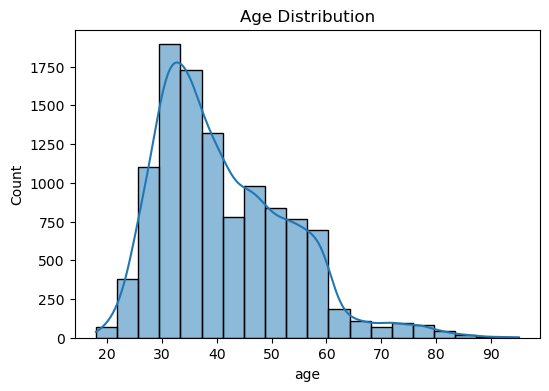

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

**Job Distribution**

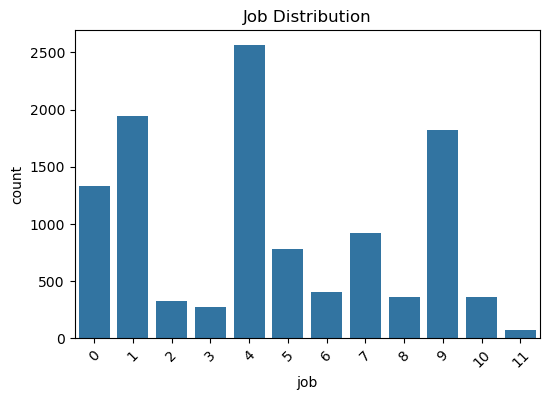

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='job', data=df)
plt.title("Job Distribution")
plt.xticks(rotation=45)
plt.show()

**Marital Status vs Loan Acceptance**

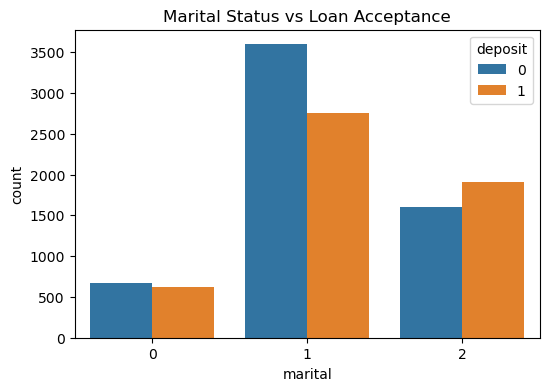

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='marital', hue='deposit', data=df)
plt.title("Marital Status vs Loan Acceptance")
plt.show()

**Model Training and Testing**

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Encode target variable (deposit: yes/no → 1/0)
le = LabelEncoder()
df['deposit'] = le.fit_transform(df['deposit'])

# Encode all categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Features and target
X = df.drop('deposit', axis=1)
y = df['deposit']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

**Evaluation Metrics**

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7895208240035826
Confusion Matrix:
 [[937 225]
 [245 826]]


**Conclusion**

The model predicts whether a customer will accept a personal loan offer. The analysis shows that features such as age, job, and marital status influence the decision. Logistic Regression provides a good accuracy for this classification task.